In [8]:
import os
import mysql.connector
from mysql.connector import Error
import time
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

def get_column_names(cursor, table_name):
    """Get all column names of a database table"""
    cursor.execute(f"DESCRIBE `{table_name}`")
    return [column[0] for column in cursor.fetchall()]

def pmax_uniqueness_ratio_sql(cursor, table_name, columns):
    """Calculates the Uniqueness Ratio for a given column permutation"""
    if not columns:
        return 0, 0
    columns_list = ', '.join([f"`{col}`" for col in columns])
    query = f"""
        SELECT 
            ((null_rows + unique_rows) / total_rows) AS uniqueness_ratio
        FROM (
            SELECT
                (SELECT COUNT(*) FROM {table_name} WHERE {' OR '.join([f"`{col}` IS NULL" for col in columns])}) AS null_rows,
                (
                    SELECT COUNT(*)
                    FROM (
                        SELECT {columns_list}
                        FROM `{table_name}`
                        WHERE {' AND '.join([f"`{col}` IS NOT NULL" for col in columns])}
                        GROUP BY {columns_list}
                        HAVING COUNT(*) = 1
                    ) AS unique_data
                ) AS unique_rows,
                (SELECT COUNT(*) FROM `{table_name}`) AS total_rows
        ) AS results;
    """
    start_time = time.time()
    cursor.execute(query)
    result = cursor.fetchone()
    execution_time = (time.time() - start_time) * 1000
    ratio = result[0] if result else 0

    return ratio, execution_time


def fit_curve1(lengths, times, degree=2):
    """Fit a polynomial curve of given degree to the lengths and times."""
    coefficients = np.polyfit(lengths, times, degree)
    polynomial = np.poly1d(coefficients)
    fitted_values = polynomial(lengths)
    SS_res = np.sum((times - fitted_values) ** 2)
    SS_tot = np.sum((times - np.mean(times)) ** 2)
    r_squared = 1 - (SS_res / SS_tot)
    return polynomial, coefficients, r_squared

def get_total_rows(cursor, database, table_name):
    cursor.execute(f"SELECT COUNT(*) FROM `{database}`.`{table_name}`;")
    total_rows = cursor.fetchone()[0]
    return total_rows


def main_sql_row_precentage(user, password, database, num, table_name, columns, row_percentages):
    execution_times = {}
    try:
        connection = mysql.connector.connect(user=user, password=password, database=database)
        if connection.is_connected():
            cursor = connection.cursor()

            total_rows = get_total_rows(cursor, database, table_name)
            # print(f"Total Rows in Table '{table_name}': {total_rows}")

            for n in range(num):
                for row_percent in row_percentages:
                    row_num = int(total_rows * row_percent)
                    # print(f"Testing {row_percent}% of rows (~{row_num} rows)")

                    cursor.execute("DROP TABLE IF EXISTS TempTable;")
                    cursor.execute(f"CREATE TABLE TempTable AS SELECT * FROM `{database}`.`{table_name}` LIMIT {row_num};")

                    ratio, exec_time = pmax_uniqueness_ratio_sql(cursor, "TempTable", columns)
                    key = row_percent

                    if key in execution_times:
                        execution_times[key].append(exec_time)
                    else:
                        execution_times[key] = [exec_time]

    except Error as e:
        print("Error:", e)
    finally:
        if connection.is_connected():
            cursor.close()
            connection.close()

    avg_execution_times_precentage = {key: sum(values) / len(values) for key, values in execution_times.items()}
    
    keys = list(avg_execution_times_precentage.keys())
    execution_values = list(avg_execution_times_precentage.values())
    fit_fn, coefficients, r_square = fit_curve1(keys, execution_values, degree=1)

    print(f"Fitting Coefficients: y = {coefficients[0]:.4f} * x + {coefficients[1]:.4f}")
    print(f"R^2: {r_square:.4f}")

    fig = plt.figure(figsize=(10, 6))
    plt.plot(keys, execution_values, 'ko-', label='Avg Execution Time')
    plt.plot(keys, fit_fn(keys), 'b--', label=f'Linear Fit (R^2={r_square:.4f})')

    for i, key in enumerate(keys):
        plt.text(key, execution_values[i], f'{execution_values[i]:.4f}', fontsize=20, ha='right')

    plt.xlabel('Percentage of Rows (%)', fontsize=20)
    plt.ylabel('Time in Milliseconds (t)', fontsize=20)
    plt.title(f'Runtime vs Number of Rows\nCurrent Key: {columns}  Table: {table_name}', fontsize=20)
    plt.grid(True)
    # plt.legend()
    
    equation_text = f"y = {coefficients[0]:.4f} * x + {coefficients[1]:.4f}"
    plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes, fontsize=16, color='blue', verticalalignment='top')

    plt.tight_layout()
    
    
    
    # -------- 保存到 Identify_key/result/rowRunTime/{table_name}Row.png --------
    def find_project_root(target="Identify_key"):
        cur = os.path.abspath(os.getcwd())
        while True:
            # 当前目录就是 Identify_key
            if os.path.basename(cur) == target:
                return cur
            # 上层目录下存在 Identify_key 目录
            candidate = os.path.join(cur, target)
            if os.path.isdir(candidate):
                return candidate
            parent = os.path.dirname(cur)
            if parent == cur:  # 已到文件系统根目录
                break
            cur = parent
        # 兜底：返回当前工作目录
        return os.path.abspath(os.getcwd())

    project_root = find_project_root("Identify_key")
    save_dir = os.path.join(project_root, "result", "rowRunTime")
    os.makedirs(save_dir, exist_ok=True)

    file_name = f"{table_name}Row.png"
    file_path = os.path.join(save_dir, file_name)

    plt.savefig(file_path, dpi=300)
    plt.show()

    print(f"✅ Plot saved to: {os.path.abspath(file_path)}")


    return avg_execution_times_precentage


In [9]:
def main_sql_row(user, password, database, num, table_name, columns, row_nums):
    execution_times = {}
    try:
        connection = mysql.connector.connect(user=user, password=password, database=database)
        if connection.is_connected():
            cursor = connection.cursor()

            for n in range(num):
                for row_num in row_nums:
                    cursor.execute("DROP TABLE IF EXISTS TempTable;")
                    cursor.execute(f"CREATE TABLE TempTable AS SELECT * FROM `{database}`.`{table_name}` LIMIT {row_num};")

                    ratio, exec_time = pmax_uniqueness_ratio_sql(cursor, "TempTable", columns)
                    key = row_num

                    if key in execution_times:
                        execution_times[key].append(exec_time)
                    else:
                        execution_times[key] = [exec_time]

    except Error as e:
        print("Error:", e)
    finally:
        if connection.is_connected():
            cursor.close()
            connection.close()

    avg_execution_times = {key: sum(values) / len(values) for key, values in execution_times.items()}
    return avg_execution_times

# Master Table


In [10]:
import random
l1 = {
    'Goalies': ['playerID', 'year', 'tmID', 'lgID', 'GP', 'Min', 'W', 'L', 'GA', 'stint'], 'Teams': ['year', 'tmID', 'name', 'lgID', 'franchID', 'playoff', 'confID', 'divID', 'GF', 'GA'],
    'TeamVsTeam': ['year', 'lgID', 'tmID', 'oppID', 'W', 'L', 'T', 'OTL'],
    'SeriesPost': ['year', 'tmIDWinner', 'tmIDLoser', 'round', 'series', 'lgIDWinner', 'lgIDLoser', 'GoalsWinner', 'GoalsLoser', 'note'], 
    'TeamsPost': ['year', 'tmID', 'lgID', 'W', 'G', 'PIM', 'GA', 'GF', 'L', 'T'],
    'Coaches': ['coachID', 'year', 'tmID', 'lgID', 'stint', 'g', 'w', 'l', 't', 'postg'],
    'Scoring': ['playerID', 'year', 'tmID', 'lgID', 'stint', 'pos', 'GP', 'G', 'A', 'postG'], 
    'TeamSplits': ['year', 'tmID', 'lgID', 'hW', 'hL', 'hOTL', 'rW', 'rL', 'rT', 'rOTL'], 
    'AwardsPlayers': ['playerID', 'award', 'year', 'lgID', 'note', 'pos'], 
    'Master': ['playerID', 'coachID', 'firstName', 'lastName', 'nameGiven', 'legendsID', 'ihdbID', 'hrefID', 'birthYear', 'birthCountry'],
    'HOF': ['hofID', 'year', 'name', 'category'],
    'AwardsMisc': ['name', 'ID', 'award', 'year', 'lgID', 'note'],
    'Abbrev': ['Type', 'Code', 'Fullname'],
    'TeamsHalf': ['year', 'tmID', 'half', 'lgID', 'rank'],
    'GoaliesShootout': ['playerID', 'year', 'stint', 'tmID', 'W', 'L', 'SA', 'GA'],
    'ScoringSup': ['playerID', 'year', 'PPA', 'SHA'],
    'CombinedShutouts': ['year', 'month', 'date', 'tmID', 'oppID', 'R/P', 'IDgoalie1', 'IDgoalie2'],
    'ScoringSC': ['playerID', 'year', 'tmID', 'lgID', 'pos', 'GP'],
    'GoaliesSC': ['playerID', 'year', 'tmID', 'lgID', 'GP'],
    'ScoringShootout': ['playerID', 'year', 'tmID', 'stint', 'S', 'G', 'GDG'],
    'TeamsSC': ['year', 'tmID', 'lgID', 'G', 'W', 'L', 'T']
}
random_l1 = {}
for key, value in l1.items():
    random_numbers=random.sample(range(len(value)), 3)
    random_l1[key] = random_numbers
    
for key ,value in random_l1.items():
    print(key, value)
# Generate six non-repeating random numbers between 0 and 9
# random_numbers = random.sample(range(len(master_columns)), 4)
# print(random_numbers)


Goalies [5, 7, 4]
Teams [1, 2, 4]
TeamVsTeam [1, 7, 2]
SeriesPost [1, 6, 0]
TeamsPost [6, 0, 2]
Coaches [5, 6, 2]
Scoring [6, 4, 8]
TeamSplits [2, 9, 3]
AwardsPlayers [5, 4, 2]
Master [8, 5, 0]
HOF [2, 1, 3]
AwardsMisc [3, 0, 1]
Abbrev [1, 0, 2]
TeamsHalf [0, 1, 3]
GoaliesShootout [4, 0, 3]
ScoringSup [2, 3, 1]
CombinedShutouts [3, 6, 7]
ScoringSC [0, 2, 5]
GoaliesSC [2, 1, 3]
ScoringShootout [6, 1, 2]
TeamsSC [0, 2, 5]


In [11]:
columns_l1 = {}
for key, value in random_l1.items():
    columns=[]
    l1_columns = l1[key]
    # print(l1_columns)
    for v in value:
        columns.append(l1_columns[v])
    random_l1[key] = columns

# random_l1 stores the random key selected for each table
for key,value in random_l1.items():
    print(key, value)

Goalies ['Min', 'L', 'GP']
Teams ['tmID', 'name', 'franchID']
TeamVsTeam ['lgID', 'OTL', 'tmID']
SeriesPost ['tmIDWinner', 'lgIDLoser', 'year']
TeamsPost ['GA', 'year', 'lgID']
Coaches ['g', 'w', 'tmID']
Scoring ['GP', 'stint', 'A']
TeamSplits ['lgID', 'rOTL', 'hW']
AwardsPlayers ['pos', 'note', 'year']
Master ['birthYear', 'legendsID', 'playerID']
HOF ['name', 'year', 'category']
AwardsMisc ['year', 'name', 'ID']
Abbrev ['Code', 'Type', 'Fullname']
TeamsHalf ['year', 'tmID', 'lgID']
GoaliesShootout ['W', 'playerID', 'tmID']
ScoringSup ['PPA', 'SHA', 'year']
CombinedShutouts ['tmID', 'IDgoalie1', 'IDgoalie2']
ScoringSC ['playerID', 'tmID', 'GP']
GoaliesSC ['tmID', 'year', 'lgID']
ScoringShootout ['GDG', 'year', 'tmID']
TeamsSC ['year', 'lgID', 'L']


Fitting Coefficients: y = 4.0190 * x + 0.6942
R^2: 0.9991


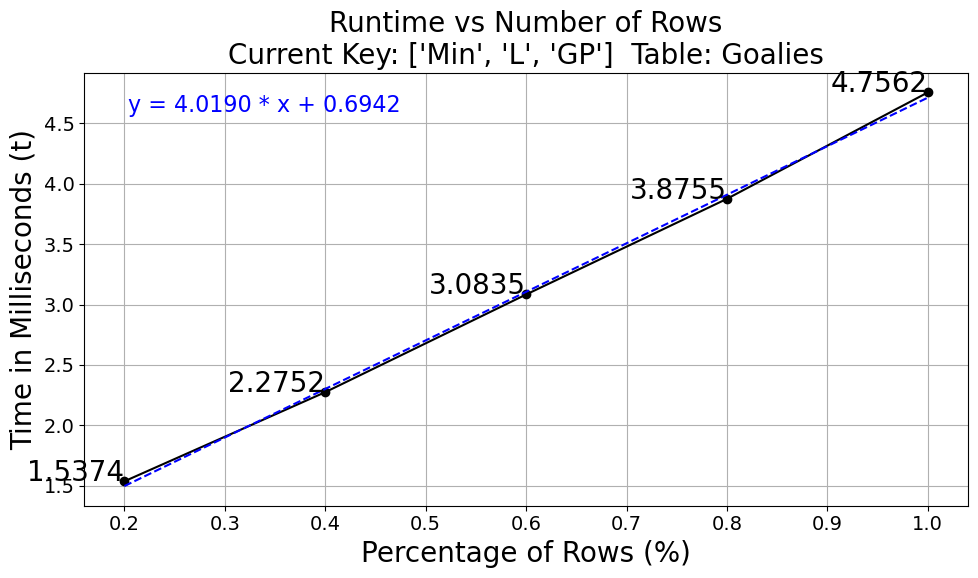

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/GoaliesRow.png
Fitting Coefficients: y = 1.4438 * x + 0.4674
R^2: 0.9942


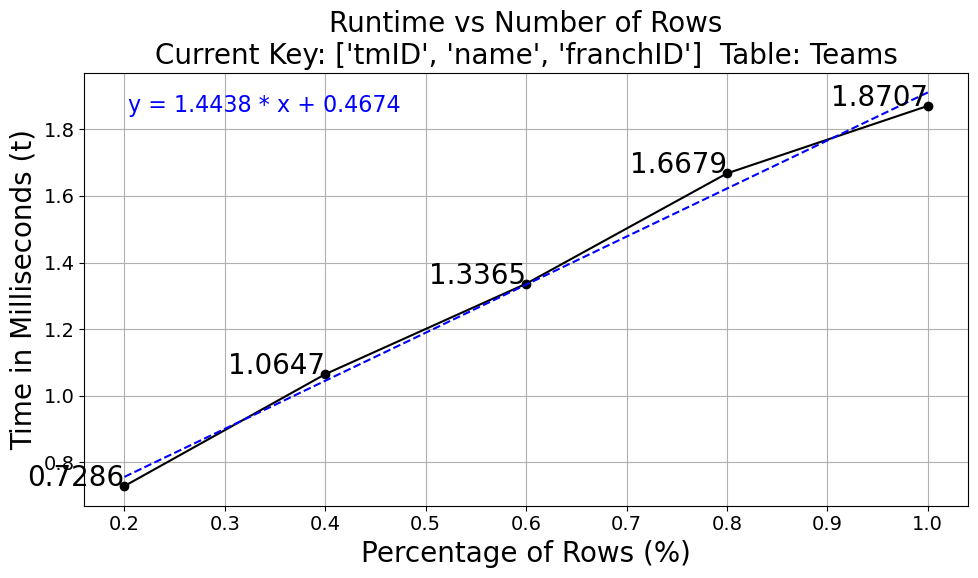

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/TeamsRow.png
Fitting Coefficients: y = 13.7594 * x + -1.1824
R^2: 0.9727


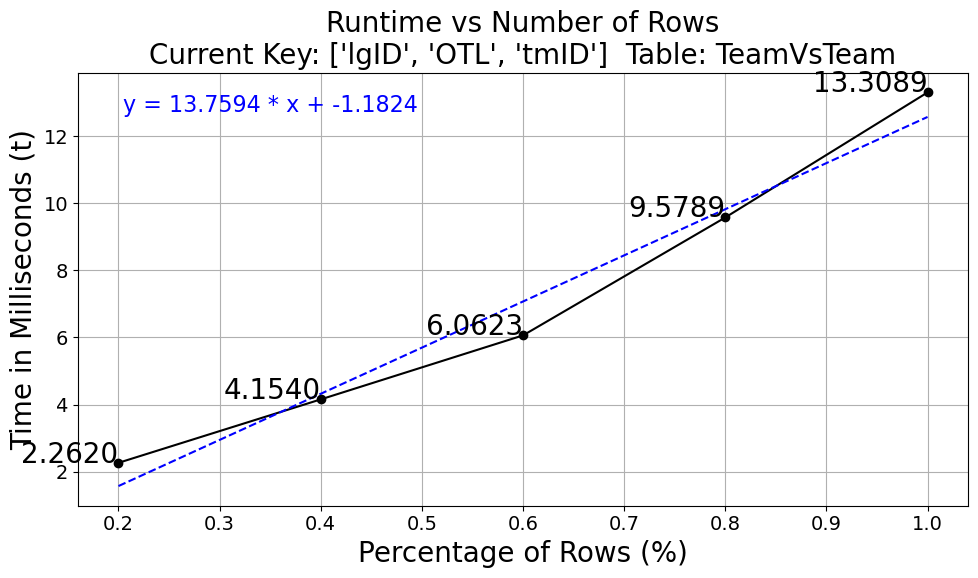

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/TeamVsTeamRow.png
Fitting Coefficients: y = 0.6191 * x + 0.3786
R^2: 0.9927


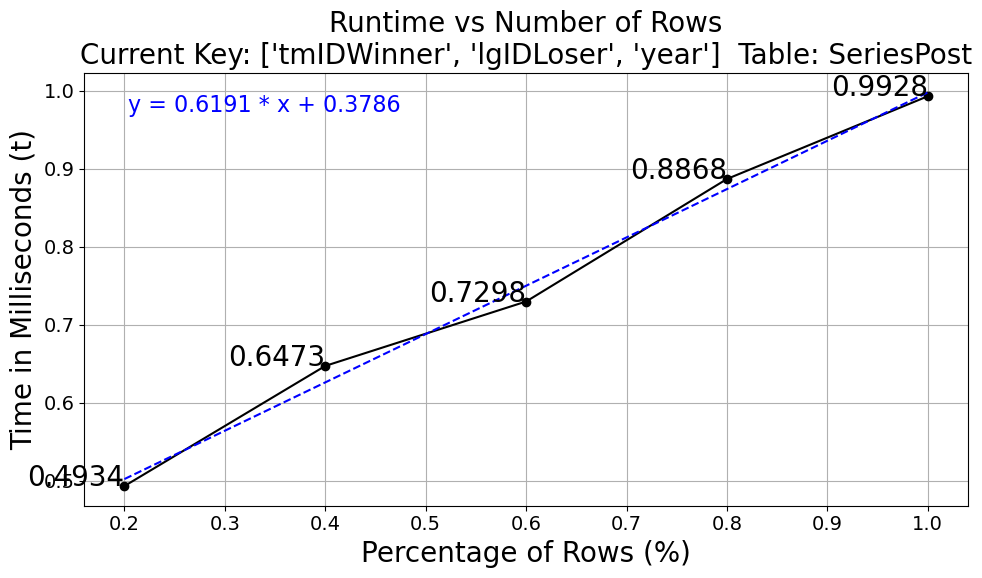

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/SeriesPostRow.png
Fitting Coefficients: y = 0.7418 * x + 0.3411
R^2: 0.9995


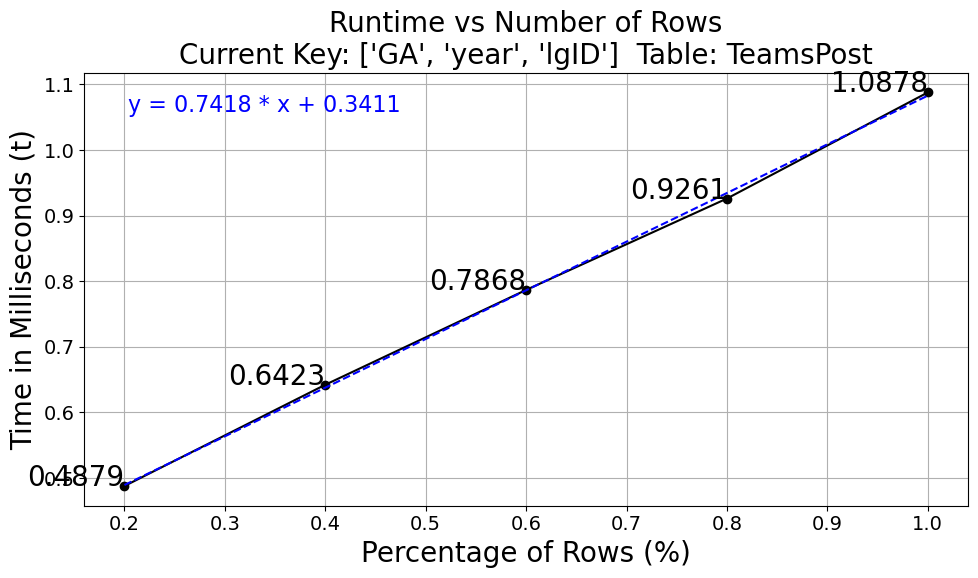

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/TeamsPostRow.png
Fitting Coefficients: y = 1.4214 * x + 0.3536
R^2: 0.9982


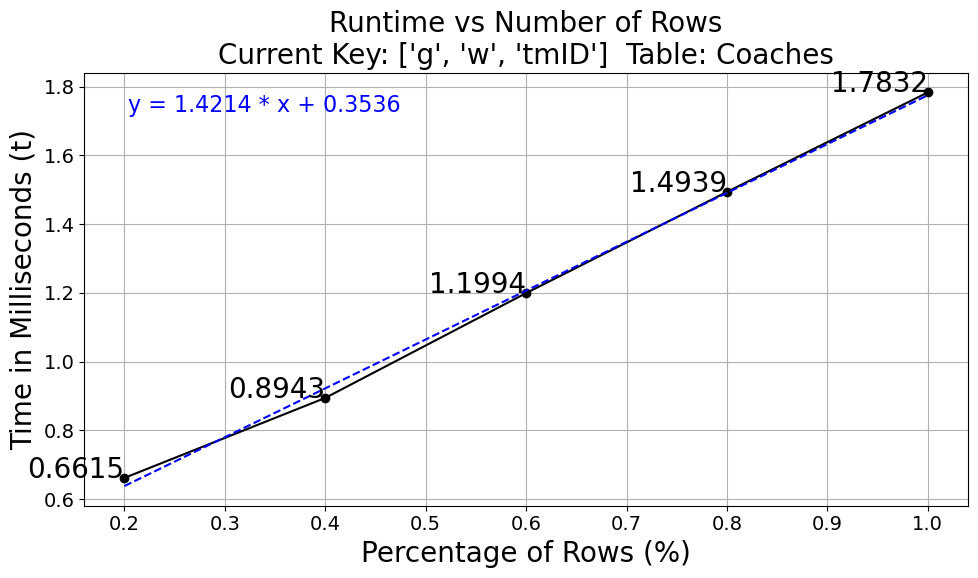

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/CoachesRow.png
Fitting Coefficients: y = 30.9754 * x + 0.1516
R^2: 0.9994


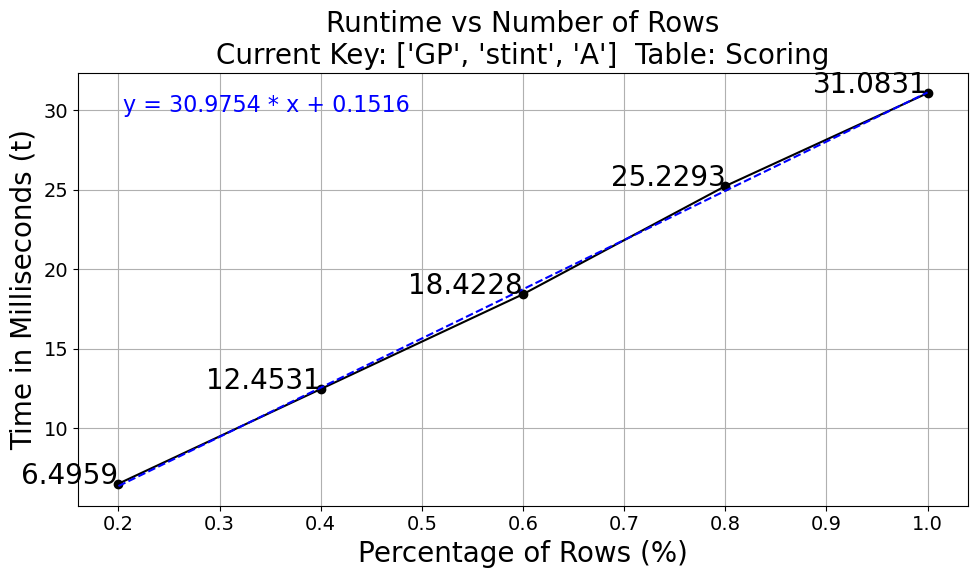

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/ScoringRow.png
Fitting Coefficients: y = 0.9394 * x + 0.3901
R^2: 0.9929


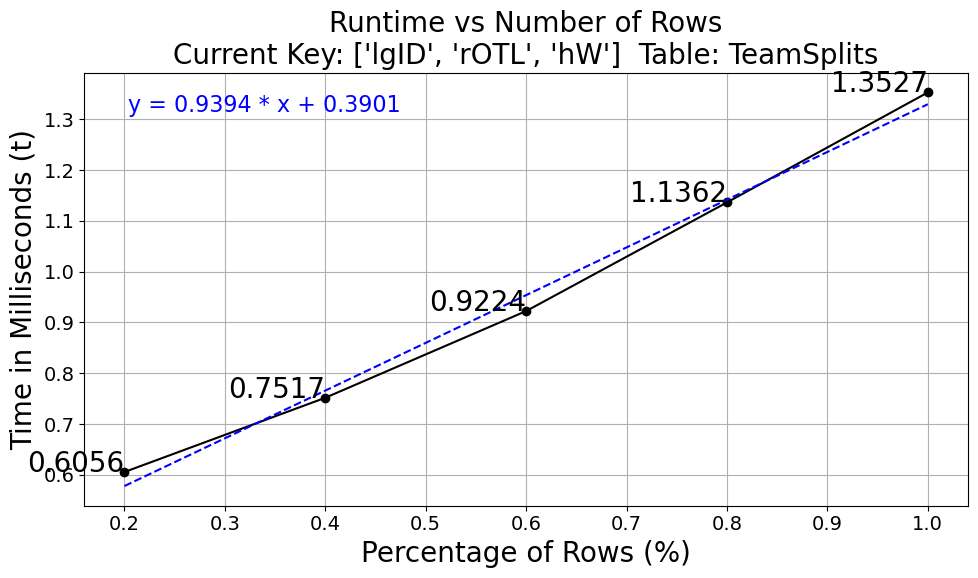

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/TeamSplitsRow.png
Fitting Coefficients: y = 0.7118 * x + 0.4287
R^2: 0.9954


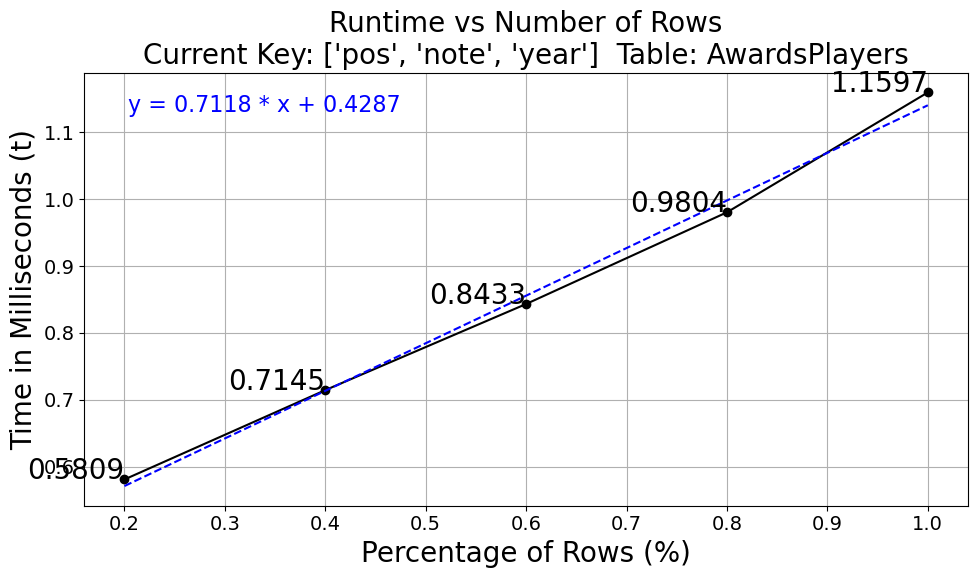

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/AwardsPlayersRow.png
Fitting Coefficients: y = 8.0215 * x + 0.5278
R^2: 0.9990


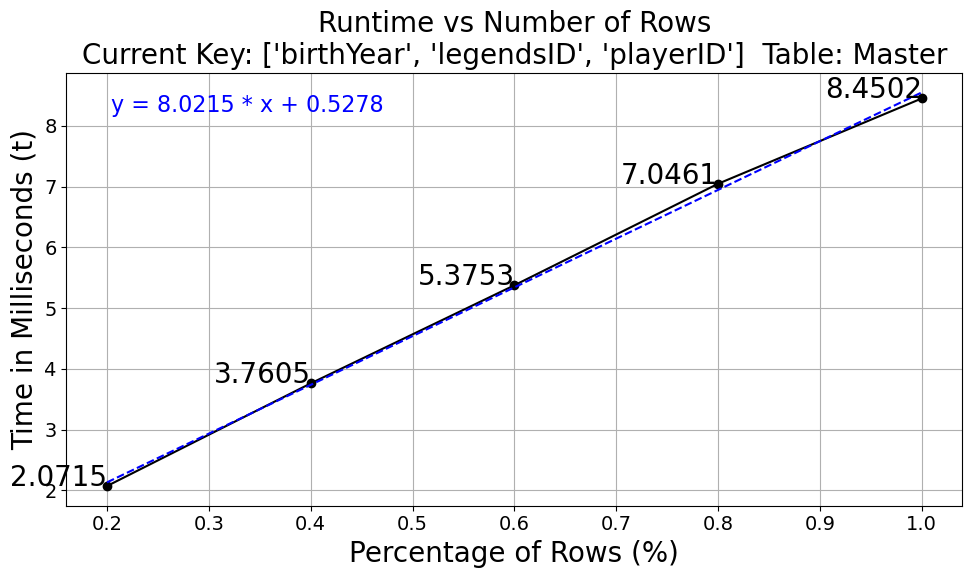

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/MasterRow.png
Fitting Coefficients: y = 0.3923 * x + 0.3548
R^2: 0.9967


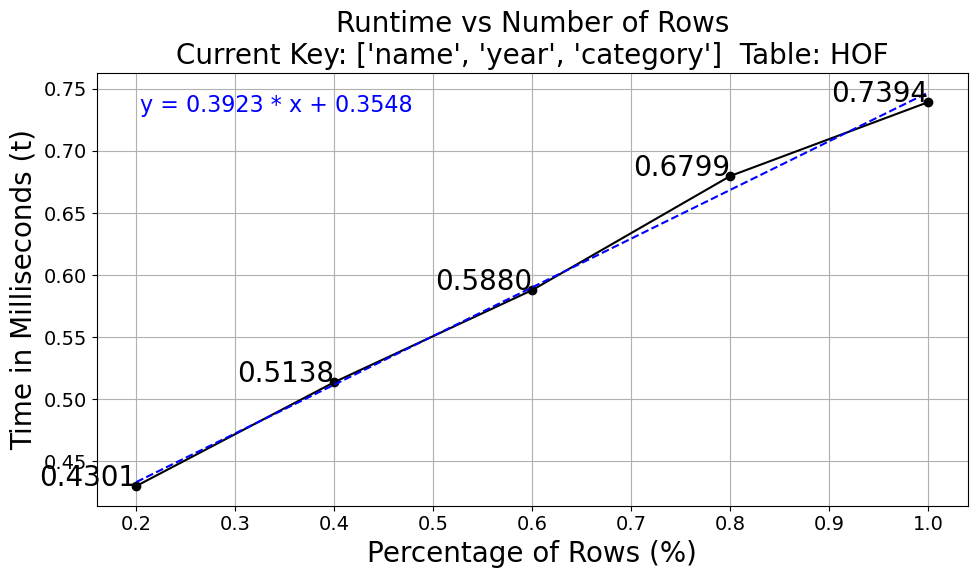

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/HOFRow.png
Fitting Coefficients: y = 0.1229 * x + 0.2863
R^2: 0.9707


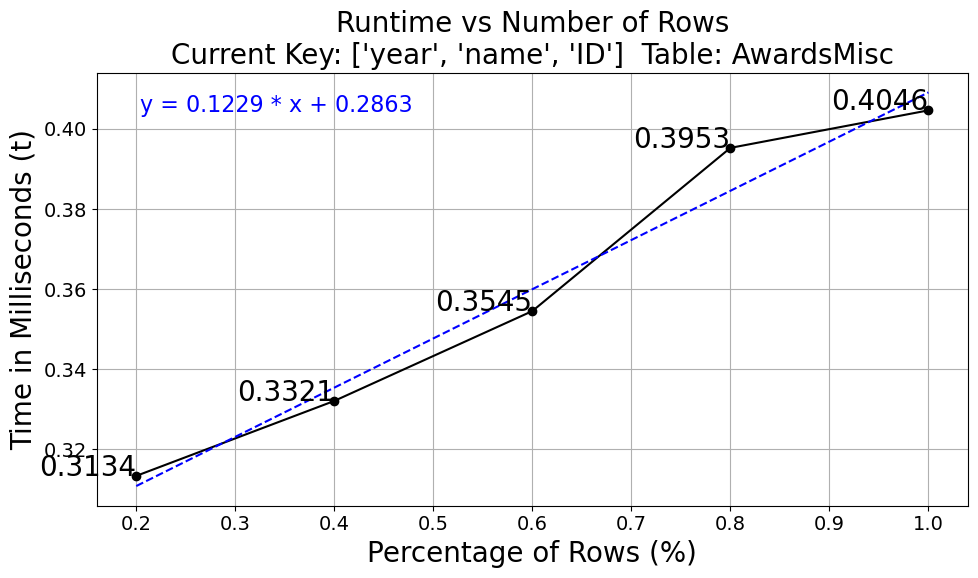

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/AwardsMiscRow.png
Fitting Coefficients: y = 0.0561 * x + 0.3014
R^2: 0.8616


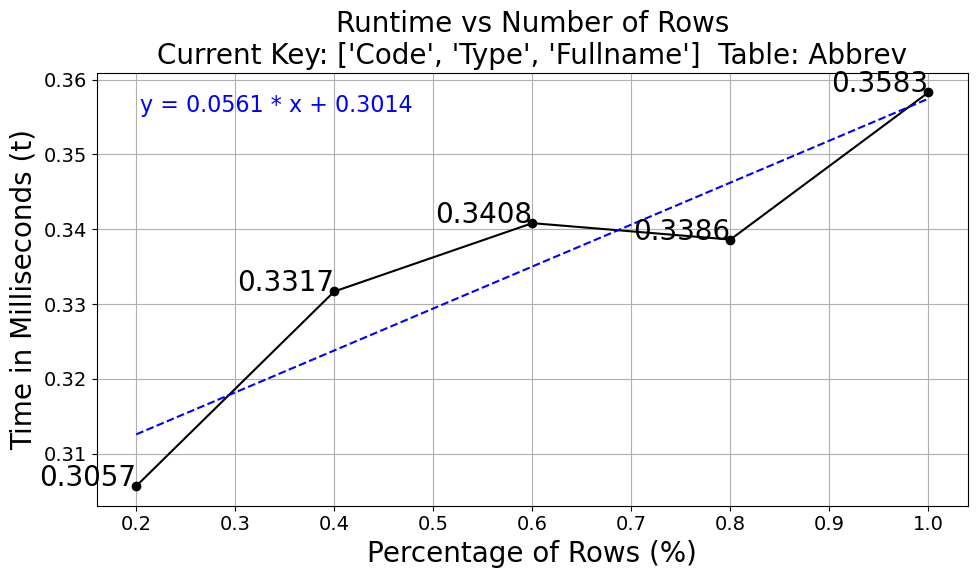

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/AbbrevRow.png
Fitting Coefficients: y = 0.0158 * x + 0.3165
R^2: 0.6932


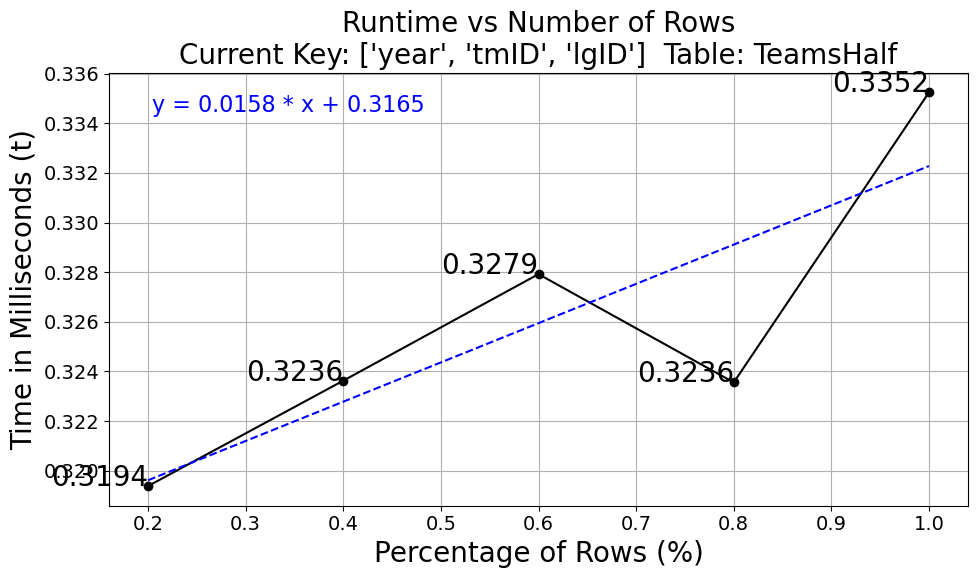

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/TeamsHalfRow.png
Fitting Coefficients: y = 0.4022 * x + 0.3223
R^2: 0.9957


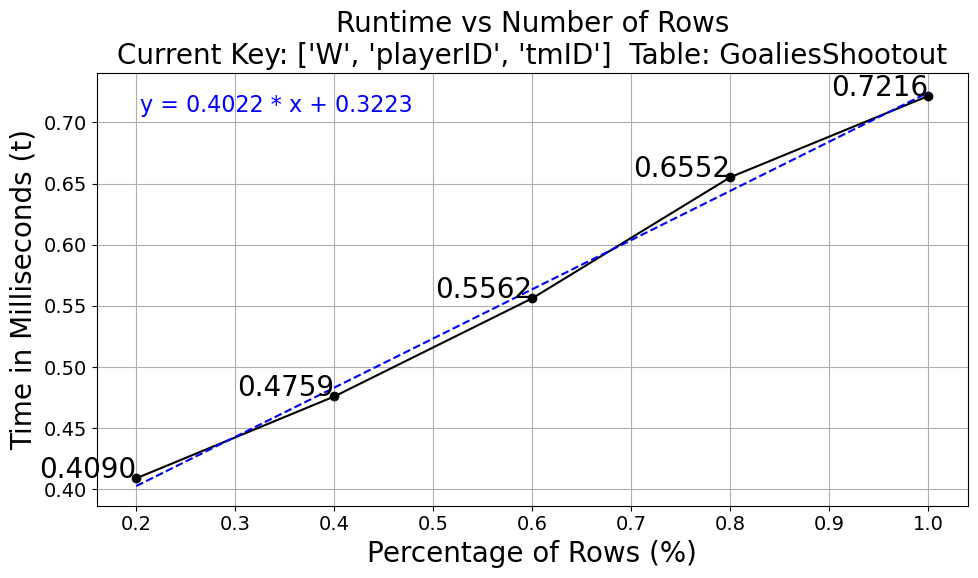

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/GoaliesShootoutRow.png
Fitting Coefficients: y = 0.0767 * x + 0.2830
R^2: 0.9484


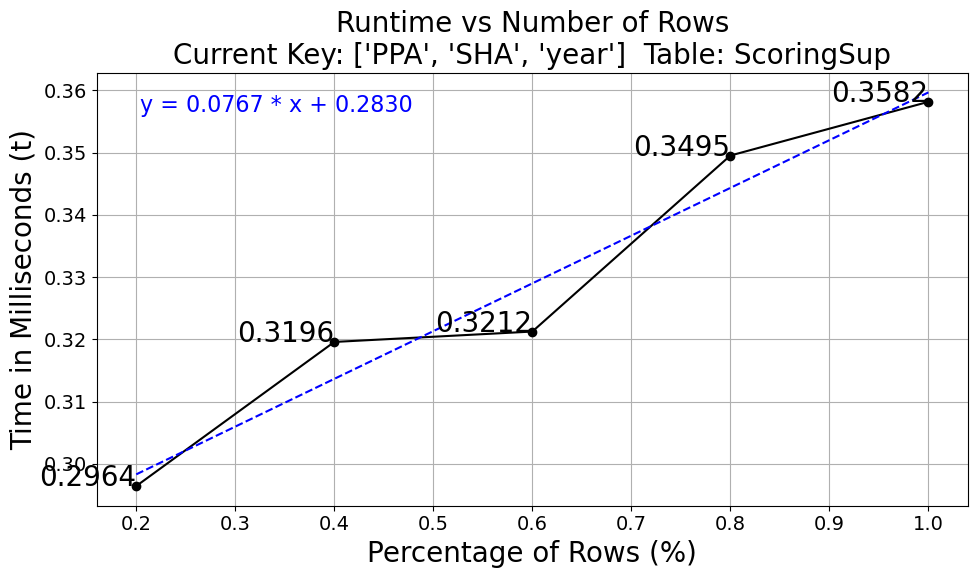

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/ScoringSupRow.png
Fitting Coefficients: y = 0.0146 * x + 0.3330
R^2: 0.4089


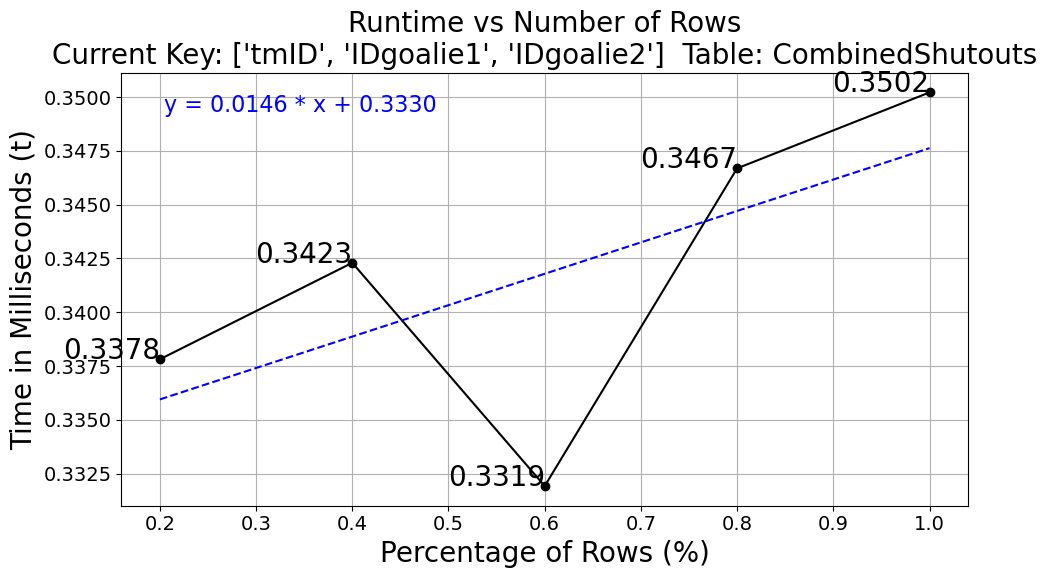

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/CombinedShutoutsRow.png
Fitting Coefficients: y = 0.2624 * x + 0.2983
R^2: 0.9954


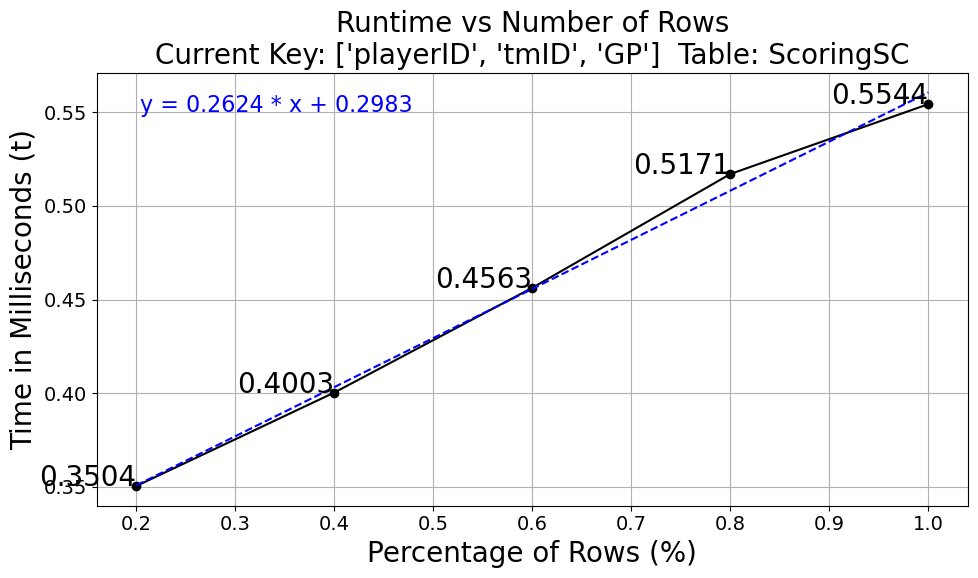

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/ScoringSCRow.png
Fitting Coefficients: y = 0.0306 * x + 0.2866
R^2: 0.7335


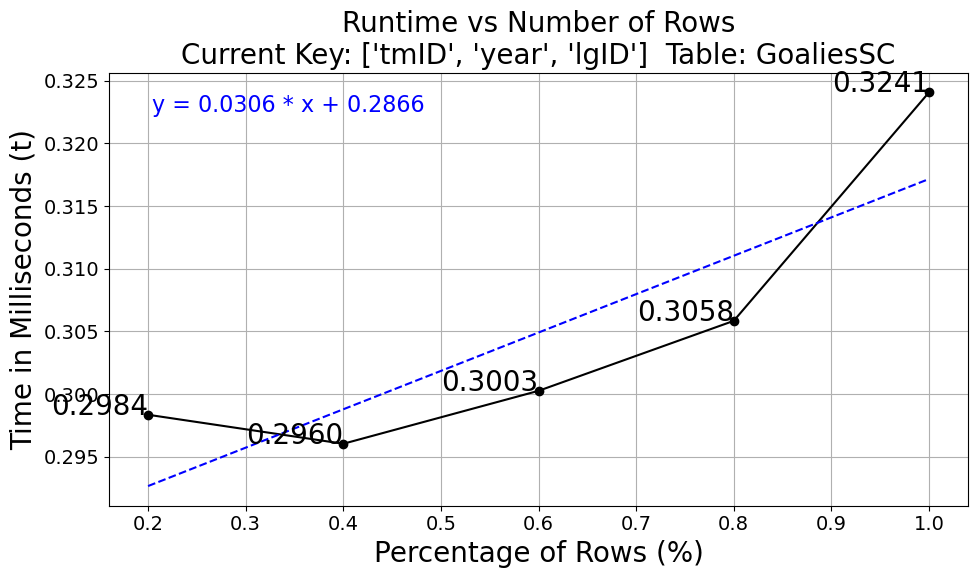

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/GoaliesSCRow.png
Fitting Coefficients: y = 1.3247 * x + 0.3676
R^2: 0.9998


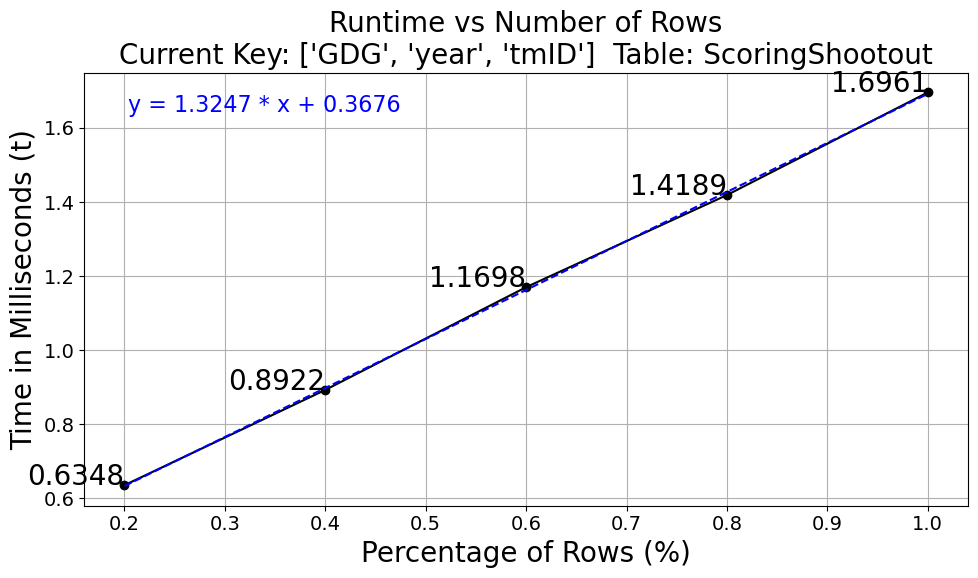

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/ScoringShootoutRow.png
Fitting Coefficients: y = 0.0530 * x + 0.3461
R^2: 0.9767


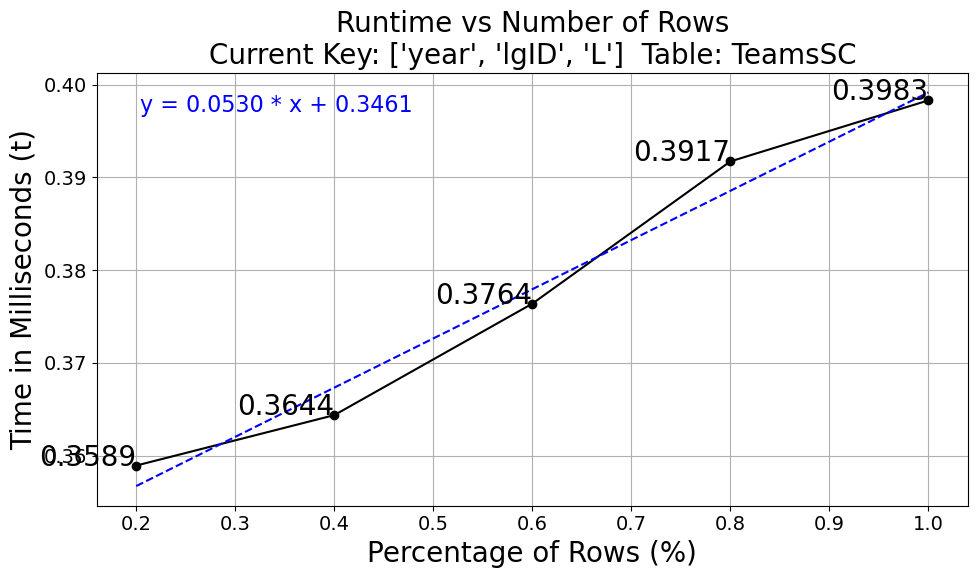

✅ Plot saved to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/TeamsSCRow.png
total_avg_execution_times_precentage: [{0.2: 1.5373706817626953, 0.4: 2.2751569747924805, 0.6: 3.083515167236328, 0.8: 3.8754940032958984, 1: 4.75618839263916}, {0.2: 0.7285594940185547, 0.4: 1.0646820068359375, 0.6: 1.3364553451538086, 0.8: 1.667928695678711, 1: 1.8707275390625}, {0.2: 2.261972427368164, 0.4: 4.154014587402344, 0.6: 6.06231689453125, 0.8: 9.578871726989746, 1: 13.308930397033691}, {0.2: 0.49343109130859375, 0.4: 0.6473302841186523, 0.6: 0.729823112487793, 0.8: 0.8867979049682617, 1: 0.9927988052368164}, {0.2: 0.48787593841552734, 0.4: 0.6422519683837891, 0.6: 0.7867813110351562, 0.8: 0.9260654449462891, 1: 1.0877609252929688}, {0.2: 0.6615400314331055, 0.4: 0.8943080902099609, 0.6: 1.1993646621704102, 0.8: 1.4938592910766602, 1: 1.7832040786743164}, {0.2: 6.495857238769531, 0.4: 12.453126907348633, 0.6: 18.422842025756836, 0.8: 25.229287147521973, 1: 31.083130836486816}, {0

In [12]:

# total_avg_execution_times = []
# avg_execution_times = main_sql_row('root', 'yzh_20010315', 'hockey', 10, "Master", columns,  [1000, 2000, 3000, 4000, 5000, 6000, 7000])
# total_avg_execution_times.append(avg_execution_times)
# print(total_avg_execution_times)
# [1000, 2000, 3000, 4000, 5000, 6000, 7000]
total_avg_execution_times_precentage = []
total_avg_execution_times=[]
for key, value in random_l1.items():
    avg_execution_times_precentage = main_sql_row_precentage('root', 'yzh_20010315', 'hockey', 10, key, value,  [0.2, 0.4, 0.6, 0.8, 1])
    total_avg_execution_times_precentage.append(avg_execution_times_precentage)
    avg_execution_times = main_sql_row('root', 'yzh_20010315', 'hockey', 10, key, value, [1000, 2000, 3000, 4000, 5000, 6000, 7000])
    total_avg_execution_times.append(avg_execution_times)
print(f"total_avg_execution_times_precentage: {total_avg_execution_times_precentage}")
print(f"total_avg_execution_times: {total_avg_execution_times}")

# Average Running Time

Polynomial Fit (degree=1): y = 3.1145 * x^1 + 0.2879 * x^0
R^2 (degree=1): 0.9981
Polynomial Fit (degree=2): y = 0.4988 * x^2 + 2.5160 * x^1 + 0.4276 * x^0
R^2 (degree=2): 0.9996
Polynomial Fit (degree=3): y = -0.5359 * x^3 + 1.4634 * x^2 + 2.0101 * x^1 + 0.4996 * x^0
R^2 (degree=3): 0.9996
Exponential Fit: y = 0.8489 * e^(1.4264 * x)
R^2 (exponential): 0.9825


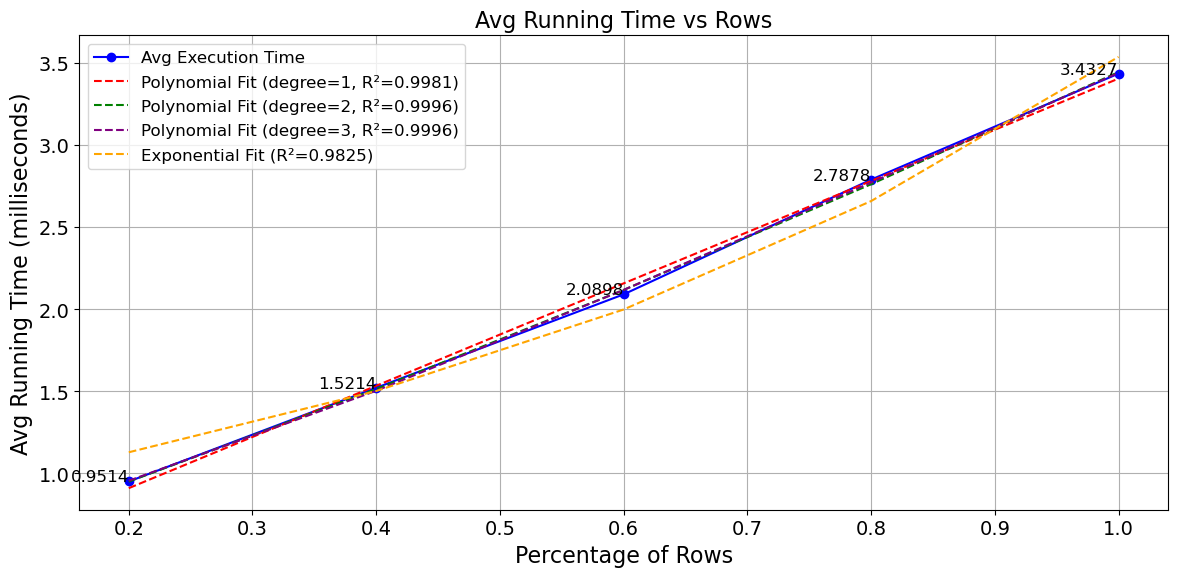

✅ Figure saved successfully to: /Users/zihuiyang/PycharmProjects/Identify_key/result/rowRunTime/change_row_fitting.png


In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def fit_curve2(lengths, times, degree=1):
    """Fit a polynomial curve of given degree to the lengths and times."""
    coefficients = np.polyfit(lengths, times, degree)
    polynomial = np.poly1d(coefficients)
    fitted_values = polynomial(lengths)
    SS_res = np.sum((times - fitted_values) ** 2)
    SS_tot = np.sum((times - np.mean(times)) ** 2)
    r_squared = 1 - (SS_res / SS_tot)
    return polynomial, coefficients, r_squared


def exponential_func(x, a, b):
    """Exponential function for curve fitting."""
    return a * np.exp(b * x)


# ---------------- 数据处理 ----------------
average_times_precentage = {}
for key in total_avg_execution_times_precentage[0].keys():
    average_times_precentage[key] = sum(d[key] for d in total_avg_execution_times_precentage) / len(total_avg_execution_times_precentage)

keys = np.array(list(average_times_precentage.keys()))
runtime = np.array(list(average_times_precentage.values()))

# ---------------- 多项式拟合 ----------------
fit_results = {}
for degree in [1, 2, 3]:
    polynomial, coefficients, r_squared = fit_curve2(keys, runtime, degree=degree)
    fit_results[degree] = {
        'polynomial': polynomial,
        'coefficients': coefficients,
        'r_squared': r_squared
    }

# ---------------- 指数拟合 ----------------
popt, pcov = curve_fit(exponential_func, keys, runtime, p0=(1, 0.1))
a, b = popt
fitted_exponential = exponential_func(keys, a, b)
residuals_exp = runtime - fitted_exponential
SS_res_exp = np.sum(residuals_exp ** 2)
SS_tot_exp = np.sum((runtime - np.mean(runtime)) ** 2)
r_squared_exp = 1 - (SS_res_exp / SS_tot_exp)

# ---------------- 输出拟合结果 ----------------
for degree in [1, 2, 3]:
    coefficients = fit_results[degree]['coefficients']
    r_squared = fit_results[degree]['r_squared']
    formula = " + ".join([f"{coefficients[i]:.4f} * x^{len(coefficients) - i - 1}" for i in range(len(coefficients))])
    print(f"Polynomial Fit (degree={degree}): y = {formula}")
    print(f"R^2 (degree={degree}): {r_squared:.4f}")

print(f"Exponential Fit: y = {a:.4f} * e^({b:.4f} * x)")
print(f"R^2 (exponential): {r_squared_exp:.4f}")

# ---------------- 绘图 ----------------
plt.rcParams.update({
    'font.size': 14, 
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12
})

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(keys, runtime, marker='o', linestyle='-', color='b', label='Avg Execution Time')

colors = ['r', 'g', 'purple']
for i, degree in enumerate([1, 2, 3]):
    polynomial = fit_results[degree]['polynomial']
    r_squared = fit_results[degree]['r_squared']
    ax.plot(
        keys,
        polynomial(keys),
        linestyle='--',
        color=colors[i],
        label=f'Polynomial Fit (degree={degree}, R²={r_squared:.4f})'
    )

ax.plot(keys, fitted_exponential, linestyle='--', color='orange', label=f'Exponential Fit (R²={r_squared_exp:.4f})')

for i, key in enumerate(keys):
    ax.text(key, runtime[i], f'{runtime[i]:.4f}', fontsize=12, ha='right')

ax.set_xlabel('Percentage of Rows')
ax.set_ylabel('Avg Running Time (milliseconds)')
ax.set_title('Avg Running Time vs Rows')
ax.grid(True)
ax.legend()
fig.tight_layout()

# ---------------- 保存路径 ----------------
def find_project_root(target="Identify_key"):
    cur = os.path.abspath(os.getcwd())
    while True:
        if os.path.basename(cur) == target:
            return cur
        candidate = os.path.join(cur, target)
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    return os.path.abspath(os.getcwd())

project_root = find_project_root("Identify_key")
save_dir = os.path.join(project_root, "result", "rowRunTime")
os.makedirs(save_dir, exist_ok=True)

file_name = "change_row_fitting.png"
file_path = os.path.join(save_dir, file_name)

plt.savefig(file_path, dpi=300)
plt.show()

print(f"✅ Figure saved successfully to: {os.path.abspath(file_path)}")
